<h4>Exploration of Public Comment data</h4>

Public comment periods are a time in a government meeting where the public can generally make remarks on any topic of their choice. Some cities put constraints on this time (like that speakers only speak for 3/5 minutes) but generally people can talk about whatever is on their mind. Public comment data thus provides a window into public opinion on the local level (although, we know that people who speak at these meetings are typically not representative of the general population).

--------------------------------------------------------------------------------

Today we are going to look at a lot of comments in Seattle, Washington and Ann Arbor, MI as well as some comments in other cities to learn about what the public thinks about two important issues to municipal politics: crime and housing.

Today we'll look at:

1. Where is public comment (PC) participation more active (by city / year)?
2. How often do PC remarks mention housing or crime?
3. What stance do people take on these issues?
4. How does the stance of the mayor align with the stance of the public?


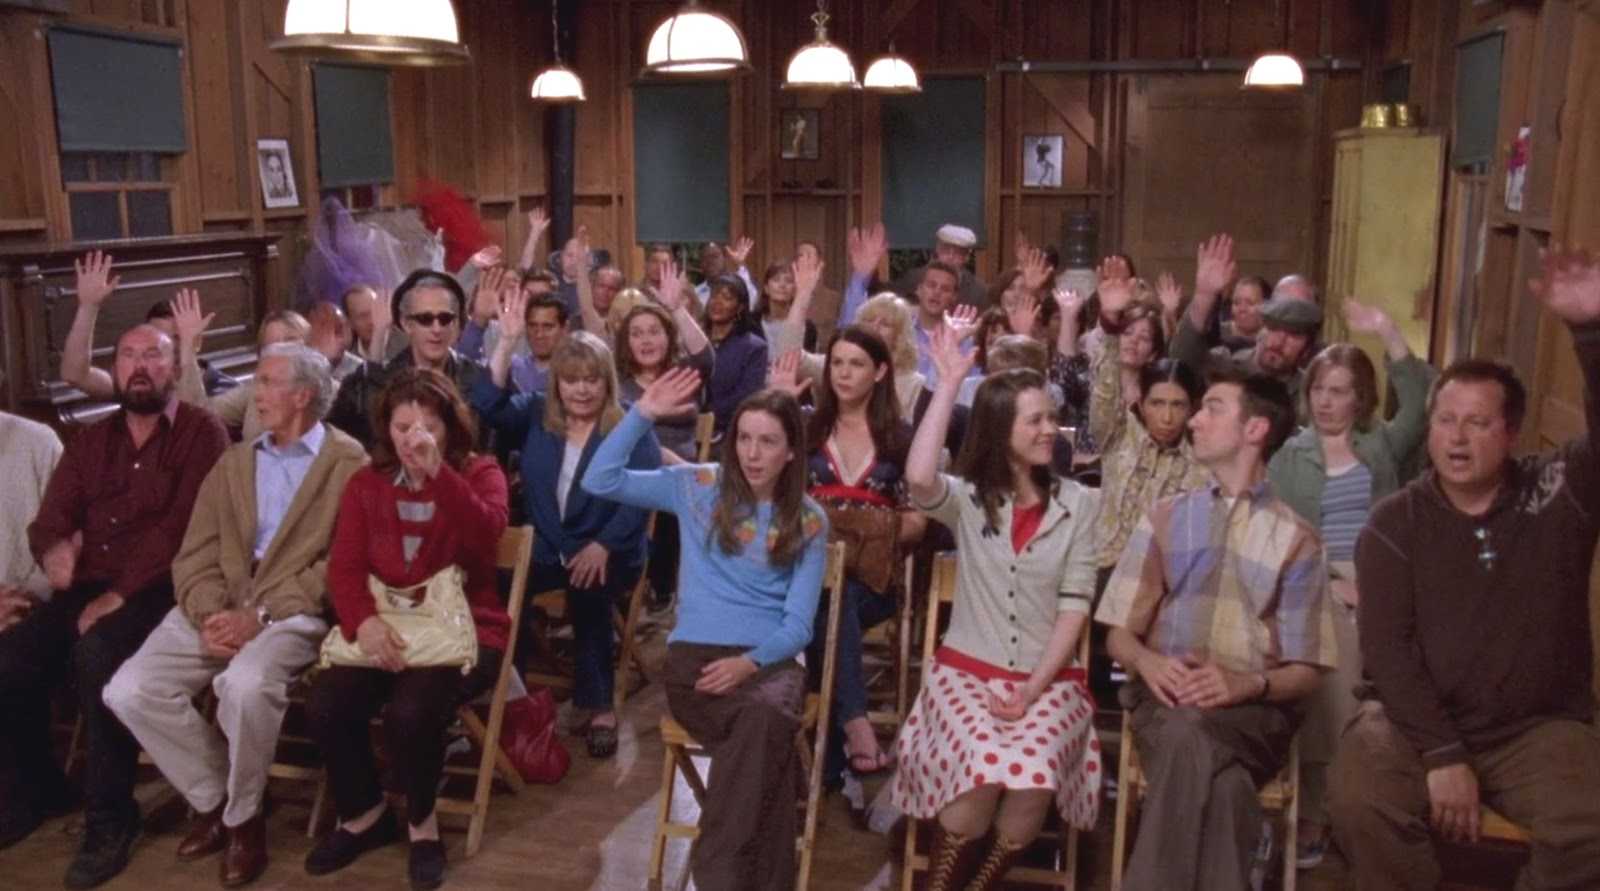

<h4>Let's get started by exploring the data</h4>

We've put together public comments from 19 cities across the US:



First, we're going to take a look at how many public comments occur in the meetings in each city. But before that, let's get our notebook set up.

Colab checklist

1. Download the [utterances](https://drive.google.com/file/d/1yAlbrP7QmjhL6-uYedt7o12fBCYhbw5a/view?usp=sharing) dataset and upload it here (You can access all of the data broken out by city and year at this  ([Drive link](https://drive.google.com/file/d/1V6GojJ-dUCmdPSNmXh7sc5kOxF1jND0I/view?usp=sharing))).

2. Run the setup cells below (install → load data → analysis).

<h3>Install Dependencies</h3>

In [ ]:
# Colab usually has pandas/matplotlib/torch; transformers may need a refresh.
%pip install -q "transformers>=4.40" accelerate sentencepiece

import torch
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU — stance inference will be slower on CPU.")

torch: 2.11.0+cpu | cuda: False
No GPU — stance inference will be slower on CPU.


<h3>Read data</h3>

In [ ]:
import pandas as pd
import re

public = pd.read_csv("utterances.csv",dtype={"fips": str})

In [ ]:
public.columns


Index(['video_id', 'city', 'state', 'year', 'start_time', 'end_time',
       'utterance', 'is_public_comment', 'is_public_hearing',
       'is_mayor_speaking'],
      dtype='object')

In [ ]:
public

,video_id,city,state,year,start_time,end_time,utterance,is_public_comment,is_public_hearing,is_mayor_speaking
0,lQNpxbRmJGk,ALBANY,CA,2019,85.370,108.635,December 16th and will you please join me in t...,False,False,True
1,lQNpxbRmJGk,ALBANY,CA,2019,109.135,116.800,Councilmember Barnes. I'd like to insert a lit...,False,False,False
2,lQNpxbRmJGk,ALBANY,CA,2019,135.136,184.998,I want to reiterate to everyone here and to th...,False,False,True
3,lQNpxbRmJGk,ALBANY,CA,2019,195.167,398.506,"This is a long one, so settle in, get comfy. C...",False,False,False
4,lQNpxbRmJGk,ALBANY,CA,2019,409.688,410.089,"Well, gosh.",False,False,False
...,...,...,...,...,...,...,...,...,...,...
36360,B0uhvx46VhM,TAZEWELL,VA,2023,1866.574,1893.207,I look forward to serving on this council and ...,False,False,False
36361,B0uhvx46VhM,TAZEWELL,VA,2023,1893.287,1937.369,I'd like to make a comment as well. I know mos...,False,False,False
36362,B0uhvx46VhM,TAZEWELL,VA,2023,1939.449,1952.312,Anything else? I encourage any elected officia...,False,False,False
36363,B0uhvx46VhM,TAZEWELL,VA,2023,1956.172,1964.174,"Alright, so my favorite part, could I get a......",False,False,True


In [ ]:
print(f"City with the most public comments {public.groupby("city")["utterance"].count().idxmax()} \
({public.groupby("city")["utterance"].count().max()} comments)")
print(f"City with the least public comments {public.groupby("city")["utterance"].count().idxmin()} \
({public.groupby("city")["utterance"].count().min()} comments)")


City with the most public comments SEATTLE (14684 comments)
City with the least public comments TAZEWELL (322 comments)


<h3>Housing</h3>

Housing is a local policy issue. Zoning laws - which determine what kinds of buildings can be built on a given plot of land - are decided by municipal governments. Housing has become a contentious issue in local politics, as housing prices in the US soar and availability declines.



*   In 1950 the median home price in the United States was $7,400 — only 2.5 times the median annual household income.
*   But that ratio began surging in the 2000s. Today the median home costs almost *five times* the median household income.
*   Estimates claim that US needs at least 10 million more affordable homes to meet housing needs [PBS](https://www.pbs.org/newshour/politics/the-u-s-is-short-10-million-houses-a-new-white-house-report-lays-out-a-blueprint-to-fix-that)


Critics blame the NIMBY (Not in my backyard movement) and call for local governments to create more permissive zoning. There have also been cries for better represenation in city council meetings to reduce the influence of older, wealthier, home-owners

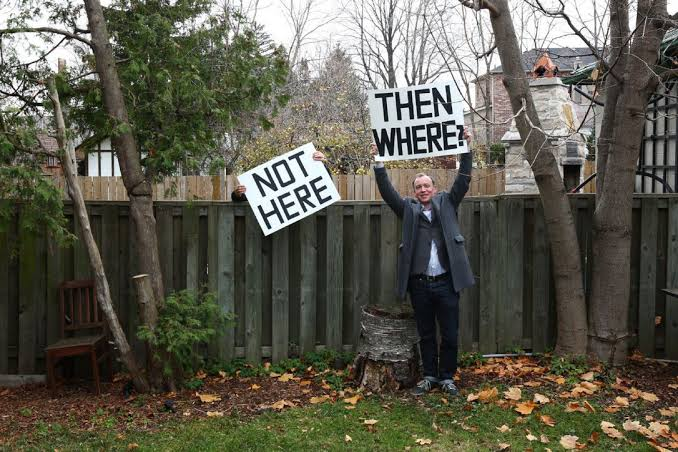

Source: [NYT Op-ed on Afforadable Housing, May 2026](https://www.nytimes.com/interactive/2026/05/18/opinion/affordable-housing-america.html)

<h4>So let's take a look at what people are saying about housing in our data</h4>

In [ ]:
# --- Keyword based search ---
HOUSING_KEYWORDS = [
    r"\bhousing\b",
    r"\baffordable housing\b",
    r"\brent\b",
    r"\blandlord\b",
    r"\btenant\b",
    r"\bzoning\b",
    r"\bdensity\b",
    r"\bapartment\b",
    r"\bstudio\b",
    r"\bshelter\b",
    r"\bhomeless\b",
    r"\bmulti[- ]family\b",
]
HOUSING_RE = re.compile("|".join(HOUSING_KEYWORDS), flags=re.IGNORECASE)

def is_about_housing(text: str) -> bool:
    """Similar housing keyword search
    """
    if not isinstance(text, str) or not text.strip():
        return False
    return HOUSING_RE.search(text) is not None


public["about_housing"] = public["utterance"].map(is_about_housing)
housing = public[(public["about_housing"])& (public['is_public_comment']==True)].copy()
print(f"Housing-topic public remarks (keyword stand-in): {len(housing):,}")


Housing-topic public remarks (keyword stand-in): 701


In [ ]:
public['is_public_comment'].sum()

np.int64(2886)

Now we are going to use an existing Zero-shot stance detector to look at attitudes around housing.

We've actually run this stance detector already, and will load the data in a minute, but for now let's run some examples in case you want to try other statements.

We'll use this model: [`NLP-Debater-Project/debertav3-stance-detection`](https://huggingface.co/NLP-Debater-Project/debertav3-stance-detection)


The model takes a particular arugment and text and predicts if this text is for or against the argument.

```text
Topic: {topic} [SEP] Argument: {argument}
```

Labels: **PRO** (supports topic) vs **CON** (opposes).

We score **PC remarks** only (already filtered above).

In [ ]:
##Stance model

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

STANCE_MODEL = "NLP-Debater-Project/debertav3-stance-detection"
MAX_PER_CITY = 40  # raise for fuller estimates
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(STANCE_MODEL)
stance_model = AutoModelForSequenceClassification.from_pretrained(STANCE_MODEL)
stance_model.to(DEVICE)
stance_model.eval()
print("device:", DEVICE)


@torch.no_grad()
def predict_stance(argument: str,topic: str) -> tuple[str, float]:
    text = f"Topic: {topic} [SEP] Argument: {argument}"
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    logits = stance_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0]
    pred = int(torch.argmax(probs).item())
    label = "PRO" if pred == 1 else "CON"
    return label, float(probs[pred].item())


config.json:   0%|          | 0.00/901 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

...

Invalid model-index. Not loading eval results into CardData.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.74GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

device: cpu


Now we are going to create a DataFrame to keep track of the stance and stance confidence.



In [ ]:
print(housing.shape)
small = housing.sample(20)
print(small.shape)

(701, 10)
(20, 10)


In [ ]:
##this is the topic we want to see if comments agree or disagree with
topic = "We urgently need more affordable apartments for working families."

In [ ]:
not_housing_test

,utterance
22264,Working Washington did not pass this law or ge...


In [ ]:
not_housings_test = public.loc[22264]['utterance']
not_housings_test

"Working Washington did not pass this law or get the numbers. Uber provided these numbers. They did not create them at all. It's assumed that each worker would be on 100% of the time, justifying the hourly wage, which is not even close to what we're going to be getting. The difference between some of the stuff from November last year to this year in January, we're pushing over $1,000 in money and $124 in the orders themselves. This time this year, we're doing 16 orders with only $169, so there's no justification in anything. The numbers provided are basically falsified as they're not even representing any kind of working wage that we're needing to be having to make numbers and to make . The bill must be repealed. There's nothing about it. Sure, we do this because we love it, not because we have to. Thank you very much."

In [ ]:
##if you want to sample

#not_housing_test = public[(public["about_housing"]==False) \
#                         & (public["utterance"].str.split().map(len)>15)\
#                         &(public["is_public_comment"]==True)]["utterance"].sample(1)
#not_housing_test.values[0]

In [ ]:
housing_test = public.loc[4751]['utterance']

In [ ]:
#if you want to sample
#housing_test = public[(public["about_housing"]==True) \
#                          & (public["utterance"].str.split().map(len)>15)\
#                          &(public["is_public_comment"]==True)]["utterance"].sample(1)
#housing_test

,utterance
26716,"And I feel that if it was them who were here, ..."


In [ ]:
housing_test

"Good evening, Council. Thank you for being here with us tonight. My name is Dylan Sheffman. I live on Forest Court in Ward 3, and I'm working as an intern at the Equitable Ann Arbor Land Trust. Over the past six months, student teams, including myself, have set out to reimagine what Ann Arbor could be for the 120,000 people who live here, the 80,000 commuters who drive in every day, and the over 6 million yearly visitors to Washtenaw County. The fact of the matter is that more people want to live in Ann Arbor than the city can accommodate at the moment. To address this, my team has designed walkable, mixed-use, transit-accessible neighborhoods spanning from university property at Plymouth and Murfin to downtown adjacent land on Fuller Road. We envision thousands of new units on unused or underused land, all to be owned by their residents, split into roughly equal thirds of affordable workforce and market rate housing. By introducing a community land trust, we have the opportunity and 

In [ ]:
predict_stance(not_housing_test,topic=topic)

('CON', 0.6432828903198242)

In [ ]:
predict_stance(housing_test,topic=topic)

('PRO', 0.9506633877754211)

In [ ]:
predict_stance("the best kind of home is a single family home even if very few people can afford one ",topic=topic)

('CON', 0.9574364423751831)

In [ ]:

x = small["utterance"].apply(predict_stance,topic=topic)
small["density_stance"] = [i[0] for i in x]
small["density_stance_conf"] = [i[1] for i in x]
small["density_stance"].value_counts()

In [ ]:
pd.set_option('display.max_colwidth', None)
small[small["density_stance"]=="PRO"]["utterance"]

,utterance
27383,"Thank you. Can you hear me now? Yes. Okay. All right. Good. Joe Kutzler here. A lot of thoughts today. First off, I'm asking that you please put I-137 on the ballot. It's important to house people who need housing help and for more people to live in the best city in the world, which would be Seattle, and to keep faith with the great hero, Heidi Wills. And this whole, speaking of which, this whole stay out of certain area zones, I know Angel Ann means well as your great city attorney, a legendary city attorney by the way, but to stay out of a drug zone should be all of Seattle. You shouldn't deal drugs anywhere, or pimp women. And frankly, pimps should meet the 864 Apache and go away. Same with Alex Zimmerman. He's a bad person, a filthy dirtbag, and has no business testifying before you with his evil Nazi salutes. America deserves better than Alex Zimmerman. We do need to score. We need to lock up Alex Zimmerman and throw away the key. We also need to lock up and throw away the... Thank you."
34067,"Democrats like Rob Saka don't want us to talk about working class candidates like Shama Salwan and her fight against warmonger Adam Smith, her fight for Congress on demands like ending the genocide in Gaza to end military aid to Israel, like the demand for rent control. the demand for free health care by taxing the rich. They don't want us to talk about working class campaigns like that because the Democratic Party is threatened by them. The Democratic Party represents the corporate landlords, they represent the military contractors, they represent big business, and they don't want working people to get organized independently to fight back. The actions of Sarah Nelson and the rest of the Democrats on this council are despicable. You just passed a resolution to honor Asian council members without recognizing the impact of your pro-landlord, pro-big-business policies on working-class Asian people who will be evicted because of you. Shama Sawant fought for 10 years for renters' rights. We won the $15 minimum wage. We defeated the Democrats' attacks on renters' rights, on ethics rules, on the $15 minimum wage."
9781,"Good evening, Ralph McKee, Fifth Ward. I have two topics tonight. First is the plan. The plan has nice goals, but it won't achieve them. It's really aspirational, wishful thinking and talking points. Triplexes sound good, but they won't help. There's little vacant land, and the cheaper houses here, say 400 grand, will be replaced by units costing 600 and up. In Seattle, they're replacing 800 grand houses with quads costing 800. That's great there. Here, if you apply that logic, the houses being replaced will be way more expensive, or the units that are replacing them will be way more expensive. The bigger buildings aren't going to be cheap either. No pricing help for 20 years. Many speakers here that you'll hear from don't seem to realize that there has to be an actual path to achieving success. There won't be any sustainability goals either because commuters can't afford $700,000 to move in. So they're not gonna move in, so no sustainability. The only way to do that is to get commuters off the road. But the biggest downside here is, I'll follow up on what Mr. Dacus said, the wide and deep transition zones that were just widened in draft three. Entire neighborhoods are now vulnerable to those big apartment buildings. Many here, Dr. Dish included, and a lot of other speakers tonight, will dispute that, but they are wrong. Please ask Brett. The parcels in those fatter zones aren't adjacent to residential areas because those areas are now, or will be, zone transition. Be honest, that part of the plan has to change. Next, you had and still have opportunities to actually do affordable housing. You put six million of the affordable housing millage into the general fund. You didn't have to. Now you're selling the Klein's lot for 17 million with no provision for using it for affordable housing. That's 23 million

<h3>Now we are going to load in data where we've precomputed the stance on comments about housing</h3>

You can find the data here: [Stance data](https://drive.google.com/file/d/1Jg6BeaB79alftkFeOM9KrLG16cxRSo2K/view?usp=sharing)

In [ ]:
stance = pd.read_csv("utterance_predictions.csv", dtype={"fips": str})
stance.columns

Index(['housing_stance', 'housing_stance_conf', 'crime_stance',
       'crime_stance_conf', 'about_housing', 'about_crime'],
      dtype='object')

In [ ]:
combined_data = public.merge(stance,left_index=True,right_index=True)
combined_data.shape[0]==public.shape[0]==stance.shape[0]
combined_data.columns

Index(['video_id', 'city', 'year', 'start_time', 'end_time', 'utterance',
       'is_public_comment', 'is_public_hearing', 'is_mayor_speaking',
       'about_housing_x', 'housing_stance', 'housing_stance_conf',
       'crime_stance', 'crime_stance_conf', 'about_housing_y', 'about_crime'],
      dtype='object')

<h4>Let's take a look at the fraction of comments about housing and how many of those are pro more affordable housing across the cities</h4>

[Text(0, 0, 'ALBANY'),
 Text(1, 0, 'ALCESTER'),
 Text(2, 0, 'AMHERST'),
 Text(3, 0, 'ANN ARBOR'),
 Text(4, 0, 'AUBURN'),
 Text(5, 0, 'BELMAR'),
 Text(6, 0, 'BRANDON'),
 Text(7, 0, 'CASTLE HILLS'),
 Text(8, 0, 'CHINO VALLEY'),
 Text(9, 0, 'COLLEGE PLACE'),
 Text(10, 0, 'COOKEVILLE'),
 Text(11, 0, 'FRANKLIN'),
 Text(12, 0, 'GLOUCESTER'),
 Text(13, 0, 'GROVES'),
 Text(14, 0, 'LACEY'),
 Text(15, 0, 'OAK HARBOR'),
 Text(16, 0, 'POQUOSON'),
 Text(17, 0, 'SEATTLE'),
 Text(18, 0, 'TAZEWELL')]

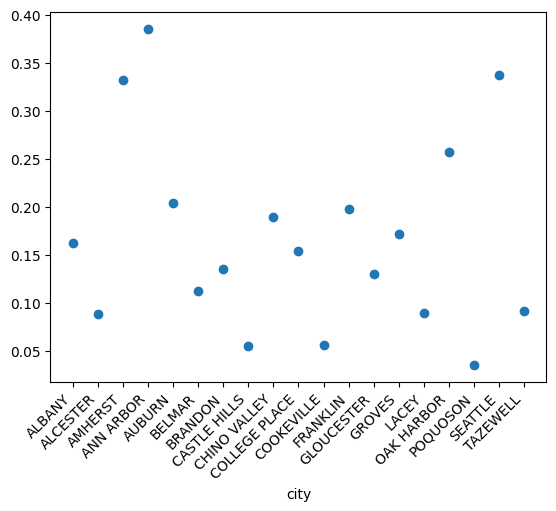

In [ ]:
housing_by_city = combined_data[combined_data["is_public_comment"]==True].groupby("city")["about_housing_y"].mean()
ax = housing_by_city.plot( marker="o",
    linestyle="None")
ax.set_xticks(range(len(housing_by_city)))
ax.set_xticklabels(
    housing_by_city.index,
    rotation=45,
    ha="right",
)

/tmp/ipykernel_2154/7413754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pro_housing['housing_stance']=pro_housing['housing_stance']\


[Text(0, 0, 'ALBANY'),
 Text(1, 0, 'ALCESTER'),
 Text(2, 0, 'AMHERST'),
 Text(3, 0, 'ANN ARBOR'),
 Text(4, 0, 'AUBURN'),
 Text(5, 0, 'BELMAR'),
 Text(6, 0, 'BRANDON'),
 Text(7, 0, 'CHINO VALLEY'),
 Text(8, 0, 'FRANKLIN'),
 Text(9, 0, 'GLOUCESTER'),
 Text(10, 0, 'GROVES'),
 Text(11, 0, 'OAK HARBOR'),
 Text(12, 0, 'SEATTLE')]

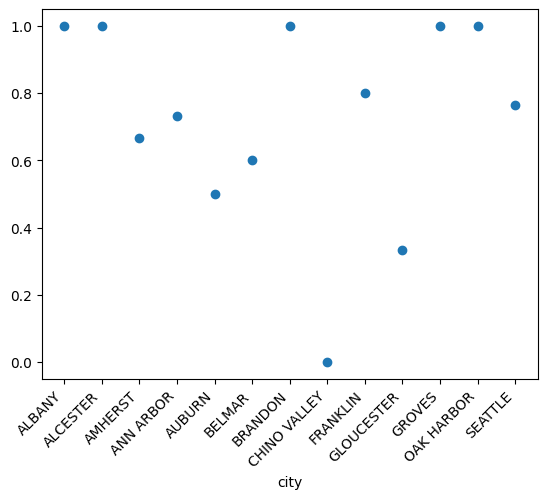

In [ ]:
pro_housing = combined_data[(combined_data["is_public_comment"]==True) & \
 (combined_data["about_housing_y"]>=.5)]

pro_housing['housing_stance']=pro_housing['housing_stance']\
.map({"PRO":True,"CON":False})

pro_housing = pro_housing.groupby("city")["housing_stance"].mean()
ax = pro_housing.plot( marker="o",
    linestyle="None")
ax.set_xticks(range(len(pro_housing)))
ax.set_xticklabels(
    pro_housing.index,
    rotation=45,
    ha="right",
)



<h4>Fun things to try:</h4>



*   Look at pro-housing stance with many different statements
*   Compare to statistics about the city like income and existing housing density
*   Build a supervised classifier that does a better job!

<h4>Some more data for you to explore</h4>

[Vote records 2024](https://drive.google.com/file/d/1eweHkqEcqS13jOFaSPY5qcChwM7kdXm0/view?usp=sharing)

[Socioeconomic data](https://drive.google.com/file/d/1a9sJn9B9phNvOmZy0lYE3P3PbiAnnziK/view?usp=sharing)

Make sure you read the FIPS in as a string like below.

In [ ]:
demos = pd.read_csv("city_socioeconomic_metadata.csv",dtype={"fips": str})
votes = pd.read_csv("city_presidential_vote_2024.csv",dtype={"fips": str})

In [ ]:
import matplotlib as plt

<h4>Now let's take a look at what the mayor has to say, and compare their position about housing and look at the two cities where we have the most comments, Seattle and Ann Arbor</h4>

We won't be able to look at the transcript data for Seattle, as the mayor doesn't attend meetings. But we'll return to Seattle in a minute.

In [ ]:
public_pro_housing_a2 = (combined_data[(combined_data["is_public_comment"]==True) & \
 (combined_data["about_housing_y"]>=.5) & \
  (combined_data["city"]=="ANN ARBOR")& \
   (combined_data["housing_stance_conf"]>.9)]["housing_stance"]=='PRO').mean()
mayor_pro_housing_a2 = (combined_data[(combined_data["is_mayor_speaking"]==True) & \
 (combined_data["about_housing_y"]>=.4)& \
  (combined_data["city"]=="ANN ARBOR")& \
   (combined_data["housing_stance_conf"]>.9)]["housing_stance"]=='PRO').mean()
print(public_pro_housing_a2 )
print(mayor_pro_housing_a2)

0.8493150684931506
0.9629629629629629


In [ ]:
pd.set_option('display.max_colwidth', None)
combined_data[(combined_data["is_mayor_speaking"]==True) & \
 (combined_data["about_housing_y"]>=.8)& \
  (combined_data["city"]=="ANN ARBOR") & \
   (combined_data["housing_stance_conf"]>.95)]["utterance"]

,utterance
3277,"a set of cooperatives here in our town who we want to do everything we can to assist and improve and expand. And then, too, of course, we have our renters. We know that we as a body have the ability to do some things in order to improve their lives a lot here in the city, and we're, I think, delighted to have taken that step, delighted to listen to the Rental Commission and others who understand best those dynamics and those needs. And I'm just glad that this government is taking real and active steps and eager to do more. Further discussion? All in favor? Opposed? It is approved. C-1, an ordinance to amend section, pardon me, chapter 42, open space and parkland preservation of Title III of the Code of the City of Ann Arbor, moved by Councilmember Deena, seconded by Councilmember Watson. Discussion, please, of C-1. Councilmember Deena."
3814,"Substantial challenge and impediment to the long-term success of our community. It has social consequences, it has consequences that are personal to community members, and it has economic consequences. We have a supply We are supply-constrained, and we have been so with intentionality, and it has resulted in the community that we have. The community that we have is economically segregated, and because of America, it is racially segregated, and that's not okay. Not going to be solved to conclusion with this project, but this project is one in a line of projects in which we will focus on creating housing supplies so that we can work to effect and accomplish long-term community change and I believe community benefit. Further discussion? All in favor? Opposed? It is approved. B3, an ordinance to amend Section 263 of Chapter 29, Water Rates of Title II of the Code of the City of Ann Arbor. We have a motion, please, moved by Councilmember Briggs, seconded by Councilmember Ayer. Discussion of B3. Councilmember Dish."
3834,"In reliance upon Councilmember Dish's recommendation, I too will support the resolution. Further discussion? All in favor? Opposed? It is approved. C1, an ordinance to amend the zoning map being a part of Section 5.10.2 of Chapter 55 of Title 5 of the Code of the City of Ann Arbor of 1.3 acres from R4C Multifamily Residential District to PUD, Planned Unit Development 732 Packard PUD zoning and supplemental regulations. Moved by Councilmember Dish, seconded by Councilmember Cornell. Discussion, please, of C1. Councilmember Dish?"
4915,"Further communication from Council? I would like to nominate the following appointment for approval in a one-step process today to the Housing Commission, Matthew Weber. May I have a motion, please? Move by Councilmember Watson, seconded by Councilmember Song. Discussion? All in favor? All opposed? It is approved with 11 councilmembers present, thus satisfying the eight-vote requirement. I would also like to recommend the following nomination for your consideration to the City Planning Commission, Richard Norton. We have before us the Consent Agenda. May I have a motion, please, to approve the consent? Moved by Councilmember Cornell, seconded by Councilmember Ackman. Discussion of the Consent Agenda. Councilmember Watson."
5968,"I am similarly excited about the progress that we are accomplishing with respect to TC1 zoning. We all know that we have an affordability crisis, housing crisis here in Ann Arbor. We also know that supply and demand is real. And so we are not going to do what we can to reduce demand in our city. We need to increase supply. We're not making a worse city. We're working on making a better city. And we also know that people who work in Ann Arbor ought to be able to live in Ann Arbor. That is what we're looking to accomplish by TC1 zoning. TC1 zoning will, in its ideal and optimal and envisioned form, enable property owners to build mixed-use, dense developments, which involve both commerce and housing, enabling people To live on transit corridors and to be able to get in and out of downtown more easily withou

In [ ]:
import requests
from bs4 import BeautifulSoup

<h3>Campaign pages</h3>

As we can see the mayors don't necessarily make a lot of substantive statements in council. Another source of information for their opinions on issues is their campaign pages. So let's look at the sites for the Ann Arbor and Seattle mayors.

We can also take a look at the campaign pages of the mayors.

Ann Arbor [Chris Taylor](https://www.taylorforannarbor.com/)



In [ ]:
#First let's get Ann Arbor
r= requests.get("https://www.taylorforannarbor.com/the-mayors-record")
soup = BeautifulSoup(r.content, "html.parser")

#code modified from GPT
housing_heading = soup.find(
    lambda tag: (
        tag.name in {"h2", "h3", "h4", "h5"}
        and "housing" in tag.get_text(" ", strip=True).lower()
    )
)
print("Heading:", housing_heading.get_text(" ", strip=True))
# The heading is contained in a parent <li>, which also contains
# the nested list of housing accomplishments.
housing_section = housing_heading.find_parent("li")

housing_list = housing_section.find(["ul", "ol"]) if housing_section else None

if housing_list is None:
    raise RuntimeError("Housing bullet list not found.")

housing_items_ann_arbor = [
    item.get_text(" ", strip=True)
    for item in housing_list.find_all("li", recursive=False)
]



Heading: Affordability, Tenants' Rights, & Housing


In [ ]:
taylor_housing_claims = pd.DataFrame({'statement':housing_items_ann_arbor,'mayor':['A2' for i in range(len((housing_items_ann_arbor)))] })

In [ ]:

x = taylor_housing_claims['statement'].apply(predict_stance,topic=topic)
taylor_housing_claims["housing_stance"]=[i[0] for i in x.values]
taylor_housing_claims["housing_stance_conf"]=[i[1] for i in x.values]

In [ ]:
taylor_housing_claims

,statement,mayor,housing_stance,housing_stance_conf
0,"Increased Ann Arbor’s Affordable Housing Trust Fund from a balance of $0 to $9,000,000+/year.",A2,PRO,0.959087
1,"Drafted 2020 Affordable Housing Millage, ensuring transformational investment in public housing and supportive services, with 1,200+ units built (more than doubling our supply) or in the pipeline.",A2,PRO,0.958731
2,"Focused on ‘missing middle’ units alongside public housing to allow teachers, nurses, firefighters and other workers to have access to attainable housing options.",A2,PRO,0.959829
3,"Protected renters by eliminating junk fees (including waitlist, holding, and excessive application fees), requiring cost transparency, obligating a right to renew, and passing the Green Rental Housing Ordinance for all 23,000 rental units across the city, promoting health, comfort, and savings through energy efficiency.",A2,PRO,0.958986
4,"Championed the successful fight to enable the sale of a vacant parking lot to the Ann Arbor District Library for a new downtown library with performance space, retail, and hundreds of units of housing.",A2,PRO,0.959777


<h4>Now let's grab data from Bruce Harrell, the Seattle mayor at the time of our data 2024-2025</h4>

This can be found on his campaign page [Bruce Harrell](https://www.bruceforseattle.com/one-seattle/)

In [ ]:
r= requests.get("https://www.bruceforseattle.com/one-seattle/")
soup = BeautifulSoup(r.content, "html.parser")
policy_text = soup.find("main").get_text("\n", strip=True)


In [ ]:
x = predict_stance(policy_text,topic=topic)
harrell_housing_claims = pd.DataFrame({"housing_stance":[x[0]],"housing_stance_conf":[x[1]],\
                          "statement":[policy_text],'mayor':['Harrell']})

In [ ]:
x

('PRO', 0.9051140546798706)

<h4>Seattle's mayor was recently defeated by a more progressive candidate, Katie Wilson. Let's take a look at her housing claims</h4>

These come from her campaign page: [Katie Wilson](https://www.wilsonforseattle.com/housing)

In [ ]:
wilson_claims = [


"The cost to rent or buy a home in Seattle is far too high. Too many families are paying well over a third of their income in housing costs, or leaving the city altogether. That leaves people with long, polluting commutes, and drives down enrollment at our schools. High rents also mean rising homelessness. We can’t continue to accept inaction from our elected leaders.",



"I have a proven record of winning major victories on affordable housing and renters’ rights. In 2018, when the county proposed using public funds to upgrade the billionaire-owned Mariners’ stadium, I fought to shift millions of dollars to housing instead.",



"In 2020, I led on designing and passing JumpStart Seattle, our city’s landmark tax on wealthy corporations, with the revenue dedicated above all to housing — until last year, when our current mayor Bruce Harrell diverted the bulk of those funds to plug a budget hole, because he didn’t want to anger his rich friends by raising new progressive revenue." ,



"And starting in 2021, I coordinated the Stay Housed Stay Healthy coalition, winning stronger protections for renters in Seattle and seven other jurisdictions across King County, from longer notice of rent increases to caps on move-in fees and late fees.",



"When I moved to Seattle in my early 20s, my husband and I were able to find an affordable home to rent while we built a life here, even though we didn’t have high-paying jobs lined up or savings in the bank. Today, it would be nearly impossible for another young couple to follow in our footsteps. Let’s make sure that our parents, our neighbors, and our children can afford to continue calling Seattle home."
]
wilson_housing_claims = pd.DataFrame({'statement':wilson_claims,'mayor':['Wilson' for i in range(len((wilson_claims)))] })

In [ ]:
x = wilson_housing_claims['statement'].apply(predict_stance,topic=topic)
wilson_housing_claims["housing_stance"]=[i[0] for i in x]
wilson_housing_claims["housing_stance_conf"]=[i[1] for i in x]



In [ ]:
mayor_claims = pd.concat((taylor_housing_claims,wilson_housing_claims,\
                          harrell_housing_claims))
print(mayor_claims["housing_stance"].value_counts())
mayor_claims.groupby('mayor')["housing_stance_conf"].mean()

housing_stance
PRO    11
Name: count, dtype: int64


,housing_stance_conf
mayor,
A2,0.959282
Harrell,0.905114
Wilson,0.958890


<h4>Fun things to try:</h4>



*   Extract only Harrell's sentences about housing and repeat
*   Scrape data for Yousef Rabhi [running for mayor in Ann Arbor](https://www.voteyousef.com/) - also claims to be more progressive than incumbent



<h3>Discussion</h3>

Really difficult to know local officials' actual stance. Many statements in meetings are procedural. Campaign materials are incredibly sparse.

What would you do to get a better understanding of their position on key issues?

<h3>Let's take a look at crime</h3>

Here we used the topic ``this city needs to be tough on crime''

/tmp/ipykernel_948/2836690725.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tough_on_crime['crime_stance']=tough_on_crime['crime_stance']\


[Text(0, 0, 'ALCESTER'),
 Text(1, 0, 'AMHERST'),
 Text(2, 0, 'ANN ARBOR'),
 Text(3, 0, 'AUBURN'),
 Text(4, 0, 'BELMAR'),
 Text(5, 0, 'BRANDON'),
 Text(6, 0, 'CASTLE HILLS'),
 Text(7, 0, 'CHINO VALLEY'),
 Text(8, 0, 'COLLEGE PLACE'),
 Text(9, 0, 'FRANKLIN'),
 Text(10, 0, 'GLOUCESTER'),
 Text(11, 0, 'LACEY'),
 Text(12, 0, 'OAK HARBOR'),
 Text(13, 0, 'SEATTLE')]

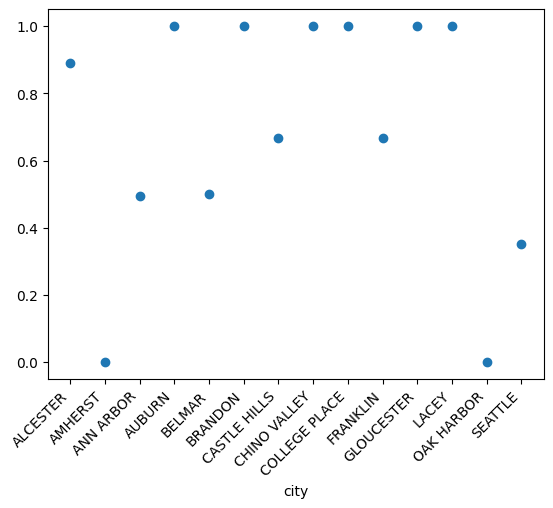

In [ ]:
tough_on_crime = combined_data[(combined_data["is_public_comment"]==True) & \
 (combined_data["about_crime"]>=.5)]

tough_on_crime['crime_stance']=tough_on_crime['crime_stance']\
.map({"PRO":True,"CON":False})

tough_on_crime = tough_on_crime.groupby("city")["crime_stance"].mean()
ax = tough_on_crime.plot( marker="o",
    linestyle="None")
ax.set_xticks(range(len(tough_on_crime)))
ax.set_xticklabels(
    tough_on_crime.index,
    rotation=45,
    ha="right",
)


<h3>Discussion</h3>

Not a lot of data but, do you think any thing is going on here? Where do you see tougher on crime attitudes?

You can load in these datasets and explore more.

<h3>Now we'll take a look at gender dynamics amongst city council officials</h3>



*   Women are more likely to be interrupted in congress (Miller and Sutherland 2023)
*   Women joining a committee lead to fewer interruptions and more on topic conversations (Ban et al. 2022)
*   At a local level there is a LOT we don't know. At at very basic level we know that there is a gender gap in terms of simple representation - only ~20\% of all mayors in cities with at least 30,000 people are women (Holman 2017)

There are a lot of open questions for you to explore. But to give a taster ...


we've put together a [small gender dataset](https://drive.google.com/file/d/1gHLgqaLNSIFnTMfTWyvAi9j_QRsR2cWk/view?usp=sharing)

*   Who speaks more frequently?
*   Who has longer utterances?

References:




Miller, Michael G., and Joseph L. Sutherland. "The effect of gender on interruptions at congressional hearings." American Political Science Review 117.1 (2023): 103-121.

Ban P, Grimmer J, Kaslovsky J, West E (2022), "How Does the Rising Number of Women in the U.S. Congress Change Deliberation? Evidence from House Committee Hearings". Quarterly Journal of Political Science, Vol. 17 No. 3 pp. 355–387, doi: https://doi.org/10.1561/100.00020112

Holman, Mirya R. "Women in local government: What we know and where we go from here." State and Local Government Review 49.4 (2017): 285-296.

In [ ]:

gender = pd.read_csv("utterances_gender.csv", dtype={"fips": str})

In [ ]:

gender.gender.value_counts()

,count
gender,
Male,571
Female,212


In [ ]:
def get_utterance_length(utt):
  return len(utt.split())
gender['u_length']= gender['utterance'].apply(get_utterance_length)

In [ ]:
gender.groupby('gender')['u_length'].mean()

,u_length
gender,
Female,45.405660
Male,48.236427


<h3>Let's take a look at the stats per city</h3>

In [ ]:
def get_speaking_gap(city_df):
  ulens = city_df.groupby('gender')['u_length'].mean()
  utts = city_df['gender'].value_counts()
  if 'Female' in ulens.index and 'Male' in ulens.index:
    return utts['Male']*ulens['Male']-utts['Female']*ulens['Female']
  else:
    print(ulens)

/tmp/ipykernel_2154/145225107.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_gaps = gender.groupby('city').apply(get_speaking_gap)


[Text(0, 0, 'ALBANY'),
 Text(1, 0, 'BRANDON'),
 Text(2, 0, 'FRANKLIN'),
 Text(3, 0, 'GROVES'),
 Text(4, 0, 'LACEY'),
 Text(5, 0, 'OAK HARBOR')]

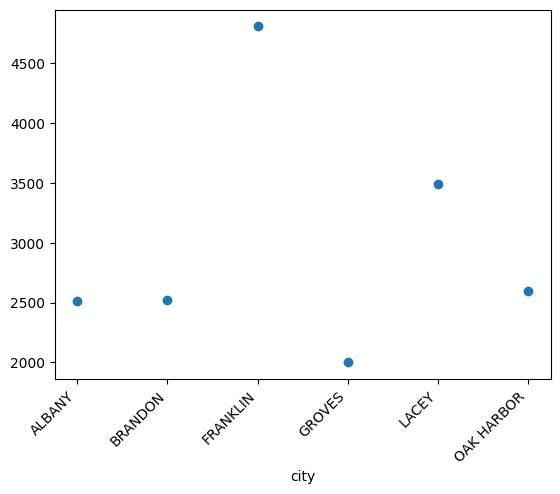

In [ ]:
city_gaps = gender.groupby('city').apply(get_speaking_gap)
ax = city_gaps.plot( marker="o",
    linestyle="None")
ax.set_xticks(range(len(city_gaps)))
ax.set_xticklabels(
    city_gaps.index,
    rotation=45,
    ha="right",
)

<h3>Discussion</h3>

What would you look at next? What are your questions about gender in local government?

How would you look at interruptions in city council discussions?